In [7]:
import pandas as pd

In [20]:
dfx = pd.read_csv('C:/users/arj26323/OneDrive - University of Georgia/Documents/Manuscripts/Network analysis/FUNDING/Funding flow.csv', encoding='cp1252')

df = dfx.copy()

for col in df.columns:
    print(col)

df

##NOTE: Double-check restoration project types!

subaward_amount
Awardees
Org name standardized
Notes
Funding source
Funding middleman 1
Funding middleman 2
Year_start
Year_end
Ongoing?
Org type
Project description
prime_awardee_name
prime_award_base_transaction_description
prime_award_fain
prime_award_amount
prime_award_program_activities_funding_this_award
prime_award_funding_office_name
prime_award_funding_sub_agency_name
prime_award_funding_agency_name
restoration_type


,subaward_amount,Awardees,Org name standardized,Notes,Funding source,Funding middleman 1,Funding middleman 2,Year_start,Year_end,Ongoing?,...,Project description,prime_awardee_name,prime_award_base_transaction_description,prime_award_fain,prime_award_amount,prime_award_program_activities_funding_this_award,prime_award_funding_office_name,prime_award_funding_sub_agency_name,prime_award_funding_agency_name,restoration_type
0,78508.00,"UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.",University of Georgia,NaN,National Oceanic and Atmospheric Administration,0001: NATIONAL OCEAN SERVICE,DEPARTMENT OF NATURAL RESOURCES,2022,NaN,NaN,...,SPATIAL & TEMPORAL PATTERNS OF DISEASE IN GEOR...,DEPARTMENT OF NATURAL RESOURCES,Georgia Coastal Management Program - Cycle 24,NA21NOS4190132,2775000.00,0001: NATIONAL OCEAN SERVICE,INTERAGENCY METEOROLOGICAL COORDINATION OFFICE,National Oceanic and Atmospheric Administration,Department of Commerce (DOC),oyster reef
1,79732.00,"UNIVERSITY OF GEORGIA RESEARCH FOUNDATION, INC.",University of Georgia,NaN,National Oceanic and Atmospheric Administration,0001: NATIONAL OCEAN SERVICE,DEPARTMENT OF NATURAL RESOURCES,2022,NaN,NaN,...,SPATIAL & TEMPORAL PATTERNS OF DISEASE IN GEOR...,DEPARTMENT OF NATURAL RESOURCES,Georgia Coastal Management Program - Cycle 24,NA21NOS4190132,2775000.00,0001: NATIONAL OCEAN SERVICE,INTERAGENCY METEOROLOGICAL COORDINATION OFFICE,National Oceanic and Atmospheric Administration,Department of Commerce (DOC),oyster reef
2,40413.00,SAVANNAH STATE UNIVERSITY,Savannah State University,NaN,National Oceanic and Atmospheric Administration,0001: NATIONAL OCEAN SERVICE,DEPARTMENT OF NATURAL RESOURCES,2022,NaN,NaN,...,EVALUATING THE USE OF BIODEGRADABLE HARDSCAPE ...,DEPARTMENT OF NATURAL RESOURCES,Georgia Coastal Management Program - Cycle 24,NA21NOS4190132,2775000.00,0001: NATIONAL OCEAN SERVICE,INTERAGENCY METEOROLOGICAL COORDINATION OFFICE,National Oceanic and Atmospheric Administration,Department of Commerce (DOC),oyster reef
3,24800.00,GEORGIA SOUTHERN UNIVERSITY RESEARCH AND SERVI...,Georgia Southern University,NaN,National Oceanic and Atmospheric Administration,0001: NATIONAL OCEAN SERVICE,"NATURAL RESOURCES, GEORGIA DEPARTMENT OF",2019,NaN,NaN,...,THE UTILITY OF RIBBED MUSSELS TO AID IN LIVING...,"NATURAL RESOURCES, GEORGIA DEPARTMENT OF",Coastal Zone Management Cycle 21,NA18NOS4190146,2379257.82,0001: NATIONAL OCEAN SERVICE,DEPT OF COMMERCE NOAA,National Oceanic and Atmospheric Administration,Department of Commerce (DOC),living shoreline
4,586250.62,GEORGIA TECH RESEARCH CORP,Georgia Institute of Technology,"Connected, this is the other portion! See othe...",Immediate Office of the Secretary of Defense,0000: UNSPECIFIED;0001: OPERATING FORCES;0004:...,NATIONAL FISH AND WILDLIFE FOUNDATION,2024,NaN,NaN,...,ASSESS RESTORATION POTENTIAL OF NATURAL INFRAS...,NATIONAL FISH AND WILDLIFE FOUNDATION,READINESS AND ENVIRONMENTAL PROTECTION INTEGRA...,HQ00342120014,86396809.10,0000: UNSPECIFIED;0001: OPERATING FORCES;0004:...,OUSD(AT & L),Immediate Office of the Secretary of Defense,Department of Defense (DOD),living shoreline
5,380000.00,CITY OF TYBEE ISLAND,City of Tybee Island,Description notes that it benefits 185 acres o...,National Oceanic and Atmospheric Administration,0001: NATIONAL OCEAN SERVICE,NATIONAL FISH AND WILDLIFE FOUNDATION,2024,NaN,NaN,...,DEVELOP FINAL DESIGN AND PERMITTING OF A NATUR...,NATIONAL FISH AND WILDLIFE FOUNDATION,In response to the direction set forth in the ...,NA23NOS4730220,32160000.00,0001: NATIONAL OCEAN SERVICE,INTERAGENCY METEOROLOGICAL COORDINATION OFFICE,National Oceanic and Atmospheric Administration,Department of Commerce (DOC),living shoreline
6,381037.41,GEORGIA TECH RESEARCH CORP,Georgia Institute of Technology,"Connected, this is the other portion! See othe...",National Oceanic and Atmospheric Administration,0000: UNKNOWN/OTHER;0001: NATIONAL OCEAN SERVICE,NATIONAL FISH AND WILDLIFE FOUNDATION,2024,NaN,NaN,...,ASSESS RESTORATION POTENTIAL OF NATU

In [13]:
import networkx as nx
from itertools import combinations

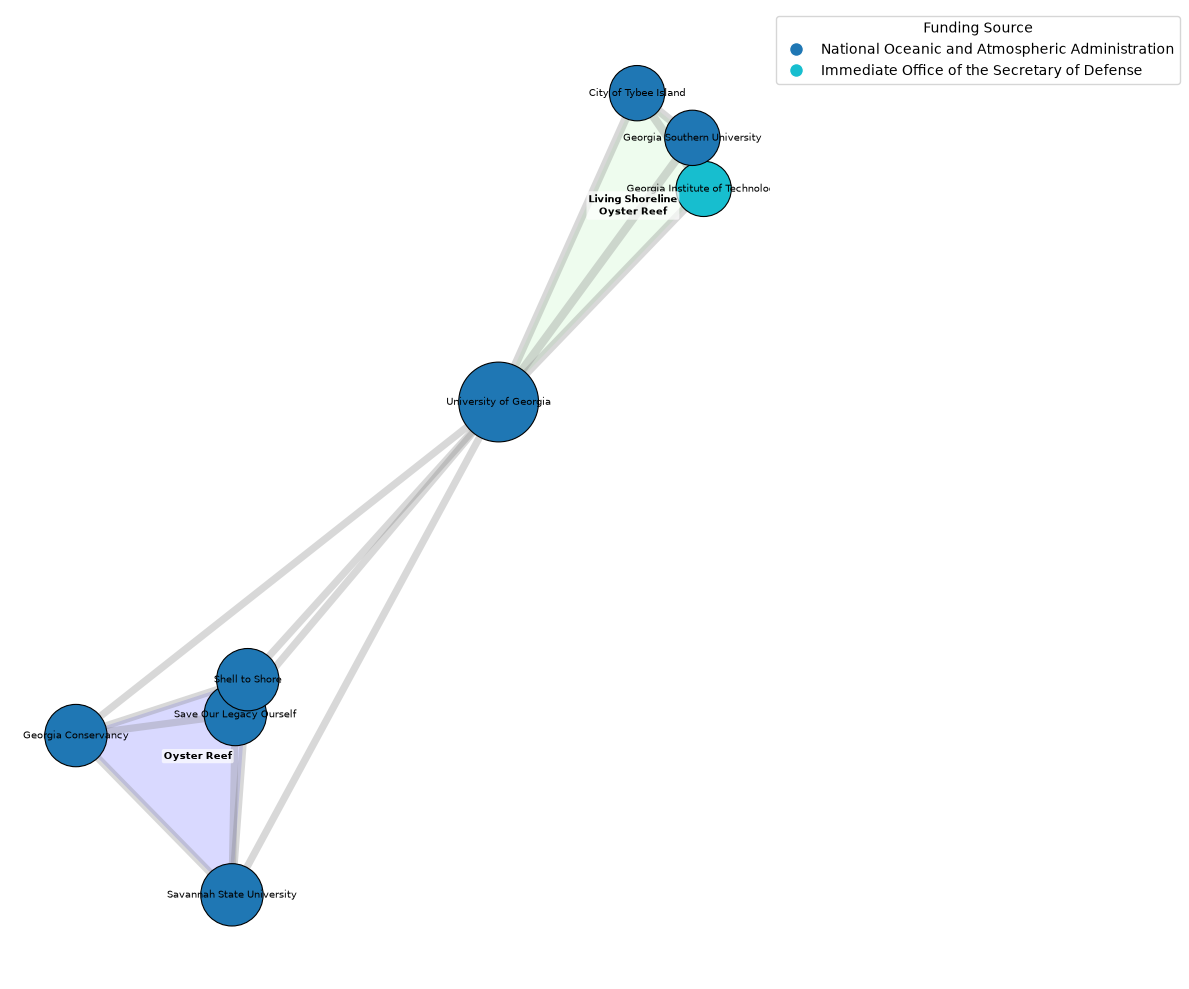

In [22]:
from collections import Counter
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import numpy as np
from scipy.spatial import ConvexHull

# ---------------------------------------------------------
# 1. GRAPH CONSTRUCTION
# ---------------------------------------------------------
G = nx.Graph()

# Add nodes with 'Funding source' attribute (first source found per org)
node_funding_map = (
    df.groupby("Org name standardized")["Funding source"].first().to_dict()
)
for node, funding in node_funding_map.items():
  G.add_node(node, funding_source=funding)

# Group organizations by shared 'restoration_type' and aggregate subaward weights
restoration_dict = {}
for _, row in df.iterrows():
  org = row["Org name standardized"]
  rest_type = row["restoration_type"]
  subaward = row["subaward_amount"]

  if pd.notna(rest_type):
    restoration_dict.setdefault(rest_type, []).append(
        {"org": org, "subaward": subaward if pd.notna(subaward) else 0}
    )

# Connect organizations sharing a restoration_type
for rest_type, entries in restoration_dict.items():
  org_names = [e["org"] for e in entries]
  # Sum total subaward amount for the shared project
  project_subaward = sum(e["subaward"] for e in entries)

  for org1, org2 in combinations(set(org_names), 2):
    if G.has_edge(org1, org2):
      G[org1][org2]["weight"] += project_subaward
      G[org1][org2]["count"] += 1
    else:
      G.add_edge(org1, org2, weight=project_subaward, count=1)

# ---------------------------------------------------------
# 2. VISUALIZATION MAPPINGS
# ---------------------------------------------------------
# Map unique funding sources to colors
funding_sources = df["Funding source"].dropna().unique()
cmap = plt.get_cmap("tab10", len(funding_sources))
palette = {
    source: color
    for source, color in zip(funding_sources, [cmap(i) for i in range(len(funding_sources))])
}

node_colors = [
    palette.get(G.nodes[n].get("funding_source"), "gray") for n in G.nodes
]

# Scale edge widths relative to subaward amounts
max_weight = max([G[u][v]["weight"] for u, v in G.edges()], default=1)
edge_widths = [
    1 + 5 * (G[u][v]["weight"] / max_weight) if max_weight > 0 else 1
    for u, v in G.edges()
]

# Scale node sizes based on degree centrality
centrality = nx.degree_centrality(G)
node_sizes = [300 + 3000 * centrality[n] for n in G.nodes]

# ---------------------------------------------------------
# 3. COMMUNITY DETECTION & CENTROID PROFILING
# ---------------------------------------------------------
communities = greedy_modularity_communities(G, weight="weight")

community_types = {}
for i, community in enumerate(communities):
  types = []
  for org in community:
    types.extend(
        df[df["Org name standardized"] == org]["restoration_type"]
        .dropna()
        .tolist()
    )
  community_types[i] = Counter(types)

# ---------------------------------------------------------
# 4. PLOTTING
# ---------------------------------------------------------
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.6, seed=3)

# Draw edges and nodes
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.3, edge_color="gray")
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.8,
    node_size=node_sizes,
)
nx.draw_networkx_labels(G, pos, font_color="black", font_size=7)

# Draw Convex Hulls for communities (groups with >=3 nodes)
hull_colors = ["blue", "lightgreen", "pink", "brown", "purple", "red"]
ax = plt.gca()

for i, community in enumerate(communities):
  points = np.array([pos[node] for node in community])
  if len(points) < 3:
    continue

  hull = ConvexHull(points)
  polygon = Polygon(
      points[hull.vertices],
      facecolor=hull_colors[i % len(hull_colors)],
      edgecolor="none",
      alpha=0.15,
      zorder=0,
  )
  ax.add_patch(polygon)

  # Community labels (top 2 restoration types)
  center = points.mean(axis=0)
  top2 = community_types[i].most_common(2)
  label = "\n".join(r_type.title() for r_type, _ in top2)

  if label:
    ax.text(
        center[0],
        center[1],
        label,
        fontsize=7,
        ha="center",
        va="center",
        weight="bold",
        bbox=dict(
            facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.2"
        ),
    )

# Add Funding Source Legend
legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=color,
        markersize=10,
        label=str(source),
    )
    for source, color in palette.items()
]
plt.legend(
    handles=legend_elements,
    title="Funding Source",
    loc="upper left",
    bbox_to_anchor=(1, 1),
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
df_projectcost = dfx.iloc[0:5, 3:5]
df_projectcost ##LS cost based on estimate using Jan MacKinnon's numbers from publication - roughly equal to 1.2 million for ten LS projects

,Named_initiative,Funding
0,We Recycle Shell,"$95,121"
1,Kings Bay effort,"$1,000,000"
2,Living Shorelines,"$1,200,000"
3,Oyster reef restoration,"$2,828,219"
4,Thin layer placement,"$6,000,000"


In [6]:
Initiative_list = {}

for _, row in df.iterrows():
    for Initiative in row["Initiatives"]:
        Initiative_list.setdefault(Initiative)

Initiative_list

{'We Recycle Shell': None,
 'Living Shorelines': None,
 'Oyster Reef Restoration': None,
 'Thin Layer Placement': None,
 'Kings Bay Effort': None}

In [7]:
# 1. Map initiative name -> dollar value
init_col = df_projectcost.columns[0]
cost_col = df_projectcost.columns[1]

# Clean currency strings (remove '$', ',', spaces) and convert to float
cleaned_costs = (
    df_projectcost[cost_col]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)

# Convert to numeric float values (turns unparseable strings into NaN, then replaces with 0)
numeric_costs = pd.to_numeric(cleaned_costs, errors="coerce").fillna(0)

# Build the cleaned lookup map
cost_map = dict(
    zip(
        df_projectcost[init_col].astype(str).str.strip(),
        numeric_costs
    )
)

In [8]:
import networkx as nx
from itertools import combinations

G = nx.Graph()

# Add nodes with organization type
for _, row in df.iterrows():
    G.add_node(
        row["Nodes"],
        org_type=row["Org type"]
    )

# Dictionary: mission -> organizations
mission_dict = {}

for _, row in df.iterrows():
    for mission in row["Initiatives"]:
        mission_dict.setdefault(mission, []).append(row["Nodes"])

# Connect organizations sharing missions
for mission, orgs in mission_dict.items():

    for org1, org2 in combinations(orgs, 2):

        if G.has_edge(org1, org2):
            G[org1][org2]["weight"] += 1
        else:
            G.add_edge(org1, org2, weight=1)

In [9]:
# 2. Build graph with cost attributes on edges
G = nx.Graph()

for _, row in df.iterrows():
    G.add_node(row["Nodes"], org_type=row["Org type"])

for mission, orgs in mission_dict.items():
    mission_cost = cost_map.get(mission, 0)
    for org1, org2 in combinations(orgs, 2):
        if G.has_edge(org1, org2):
            G[org1][org2]["total_cost"] += mission_cost
            G[org1][org2]["weight"] += 1
        else:
            G.add_edge(org1, org2, total_cost=mission_cost, weight=1)

In [10]:
org_types = df["Org type"].unique()

palette = {
    org_type: color
    for org_type, color in zip(
        org_types,
        ["red", "blue", "purple", "green",
         "orange", "pink", "gray", "brown"]
    )
}

node_colors = [
    palette[G.nodes[n]["org_type"]]
    for n in G.nodes
]

In [11]:
##Restoration, specifically
restoration_orgs = set(
    df.loc[
        df["Initiatives"].apply(lambda x: "restoration" in x),
        "Nodes"
    ]
)

node_edgecolors = [
    "gold" if node in restoration_orgs else "gold"
    for node in G.nodes
]

node_linewidths = [
    2.5 if node in restoration_orgs else 0.5
    for node in G.nodes
]

NameError: name 'node_colors' is not defined

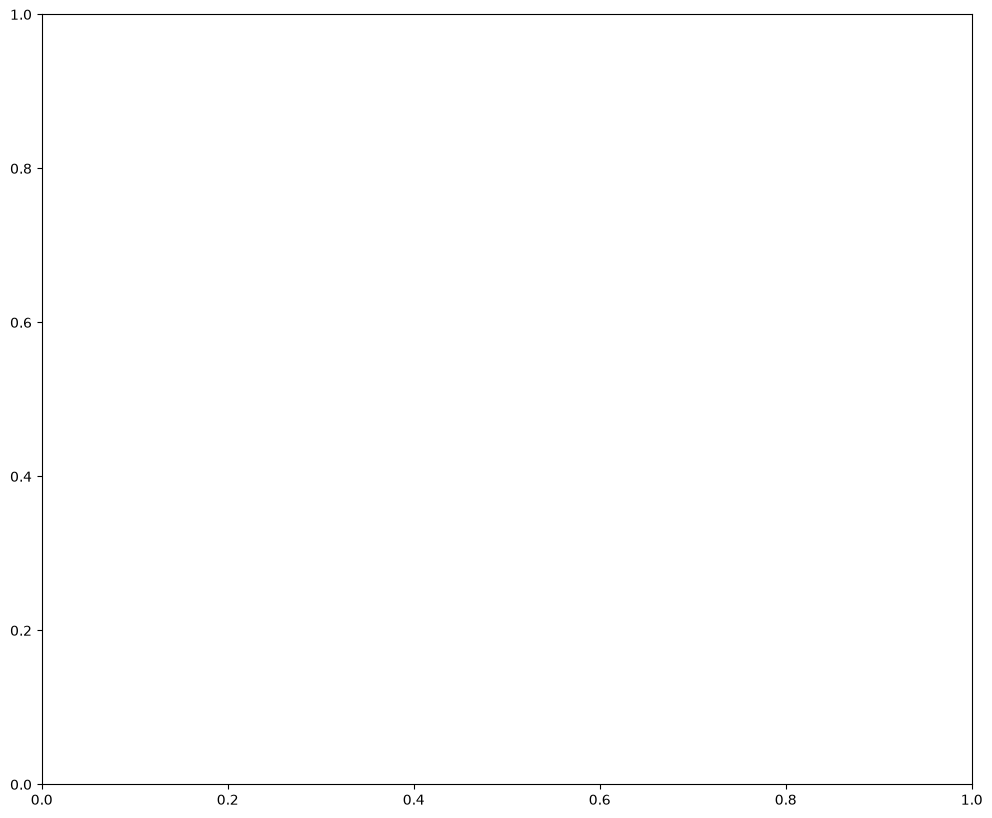

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    k=0.6,
    seed=3
)

edge_widths = [
    G[u][v]["weight"]
    for u, v in G.edges()
]

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths,
    # node_size=node_sizes,
    node_size=250
)

nx.draw_networkx_labels(
    G,
    pos,
    font_color = 'brown',
    font_size=6
)

from matplotlib.lines import Line2D

legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=color,
        markersize=10,
        label=org
    )
    for org, color in palette.items()
]

plt.legend(handles=legend)

edge_widths = [
    G[u][v]["weight"] * 1.5
    for u, v in G.edges()
]

centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 3000 * centrality[n]
    for n in G.nodes
]

from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight = "weight")

from collections import Counter

community_missions = {}

for i, community in enumerate(communities):

    missions = []

    for org in community:
        row = df[df["Nodes"] == org]
        missions.extend(row.iloc[0]["Initiatives"])

    community_missions[i] = Counter(missions)

##ADDING LABELS
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import numpy as np
ax = plt.gca()

colors = ['blue','lightgreen','pink','brown',
          'purple','red']

for i, community in enumerate(communities):

    # Coordinates of nodes in this community
    points = np.array([pos[node] for node in community])

    if len(points) < 3:
        continue

    # Draw hull
    hull = ConvexHull(points)

    polygon = Polygon(
        points[hull.vertices],
        facecolor=colors[i % len(colors)],
        edgecolor='none',
        alpha=0.20,
        zorder=0
    )

    ax.add_patch(polygon)

    # Community centroid
    center = points.mean(axis=0)

    # Top three mission types
    top2 = community_missions[i].most_common(2)

    label = "\n".join(
        mission.title() for mission, count in top2
    )

    ax.text(
        center[0],
        center[1],
        label,
        fontsize=6,
        ha='center',
        va='center',
        weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=2
        )
    )



plt.axis("off")
plt.show()

In [13]:
# Sort nodes by degree in descending order
nodes_sorted_by_degree = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)

# Print node name along with its connection count
for node in nodes_sorted_by_degree:
    print(f"{node}: {G.degree(node)} connections")


    ##ADD GCE LTER????

CRD: 22 connections
University of Georgia: 22 connections
Georgia Institute of Technology: 21 connections
The Nature Conservancy, GA : 21 connections
Jekyll Island Authority: 21 connections
NOAA: 21 connections
Georgia Sea Grant/UGA Marine Extension: 18 connections
SINERR: 18 connections
Georgia Coastal Ecosystems LTER: 18 connections
UGA Institute for Resilient Infrastructure Systems: 18 connections
Georgia Conservancy: 17 connections
Geostabilization International: 17 connections
Zulu Marine: 17 connections
Environmental Construction Solutions: 17 connections
Moffatt & Nichol: 17 connections
Robinson Design Engineers: 17 connections
City of Tybee Island: 17 connections
Americorps: 17 connections
Army Corps of Engineers: 9 connections
USFWS: 9 connections
Georgia Southern University: 9 connections
EPA: 9 connections
Shell to Shore: 6 connections


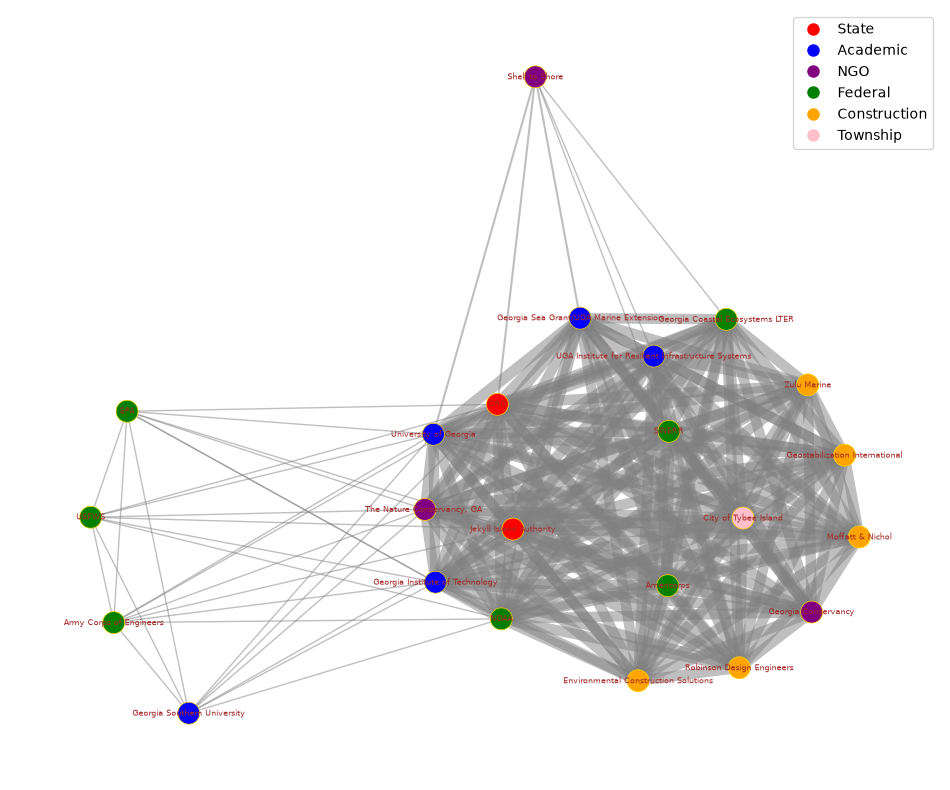

In [14]:
##Network analysis with edges sized by budget (estimated for Living shorelines)
plt.figure(figsize=(12,10))

pos = nx.spring_layout(
    G,
    k=0.6,
    seed=3
)

# 3. Normalize edge widths (e.g., scale between 1px and 8px for plotting)
costs = [d.get("total_cost", 0) for u, v, d in G.edges(data=True)]
max_cost = max(costs) if costs and max(costs) > 0 else 1

edge_widths = [
    1.0 + (G[u][v]["total_cost"] / max_cost) * 7.0 
    for u, v in G.edges()
]

# 4. Draw edges with cost-scaled widths
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.5,
    edge_color="gray"
)

centrality = nx.degree_centrality(G)

node_sizes = [
    300 + 3000 * centrality[n]
    for n in G.nodes
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    edgecolors=node_edgecolors,
    linewidths=node_linewidths,
    # node_size=node_sizes,
    node_size=250
)

nx.draw_networkx_labels(
    G,
    pos,
    font_color = 'brown',
    font_size=6
)


plt.legend(handles=legend)


from networkx.algorithms.community import greedy_modularity_communities

communities = greedy_modularity_communities(G, weight = "weight")

from collections import Counter

community_missions = {}

for i, community in enumerate(communities):

    missions = []

    for org in community:
        row = df[df["Nodes"] == org]
        missions.extend(row.iloc[0]["Initiatives"])

    community_missions[i] = Counter(missions)

# ##ADDING LABELS
# from scipy.spatial import ConvexHull
# from matplotlib.patches import Polygon
# import numpy as np
# ax = plt.gca()

# colors = ['blue','lightgreen','pink','brown',
#           'purple','red']

# for i, community in enumerate(communities):

#     # Coordinates of nodes in this community
#     points = np.array([pos[node] for node in community])

#     if len(points) < 3:
#         continue

#     # Draw hull
#     hull = ConvexHull(points)

#     polygon = Polygon(
#         points[hull.vertices],
#         facecolor=colors[i % len(colors)],
#         edgecolor='none',
#         alpha=0.20,
#         zorder=0
#     )

#     ax.add_patch(polygon)

    # Community centroid
    center = points.mean(axis=0)

    # Top three mission types
    top2 = community_missions[i].most_common(2)

    label = "\n".join(
        mission.title() for mission, count in top2
    )

    ax.text(
        center[0],
        center[1],
        label,
        fontsize=6,
        ha='center',
        va='center',
        weight='bold',
        bbox=dict(
            facecolor='white',
            alpha=0.7,
            edgecolor='none',
            pad=2
        )
    )



plt.axis("off")
plt.show()

In [15]:
df

,Nodes,Initiatives,Org type
0,CRD,"[We Recycle Shell, Living Shorelines, Oyster R...",State
1,Georgia Sea Grant/UGA Marine Extension,"[We Recycle Shell, Living Shorelines]",Academic
2,University of Georgia,"[Kings Bay Effort, Thin Layer Placement, We Re...",Academic
3,Georgia Institute of Technology,"[Kings Bay Effort, Living Shorelines, Thin Lay...",Academic
4,Shell to Shore,"[We Recycle Shell, Oyster Reef Restoration]",NGO
5,"The Nature Conservancy, GA","[Living Shorelines, Thin Layer Placement]",NGO
6,Georgia Conservancy,[Living Shorelines],NGO
7,Jekyll Island Authority,"[Thin Layer Placement, Living Shorelines]",State
8,Army Corps of Engineers,[Thin Layer Placement],Federal
9,NOAA,"[Thin Layer Placement, Living Shorelines]",Federal


In [16]:
community_missions[0].most_common(1)

[('Thin Layer Placement', 8)]

In [17]:
# from collections import Counter

# community_missions = {}

# for i, comm in enumerate(communities):
#     missions = []

#     for org in comm:
#         row = df[df["Nodes"] == org]
#         missions.extend(row.iloc[0]["Mission type"])

#     community_missions[i] = Counter(missions)

for i, counter in community_missions.items():
    print(f"\nCommunity {i}")
    for mission, count in counter.most_common():
        print(f"{mission:20} {count}")


Community 0
Thin Layer Placement 8
Living Shorelines    4
Kings Bay Effort     1

Community 1
Living Shorelines    8

Community 2
Living Shorelines    6
Oyster Reef Restoration 5
We Recycle Shell     4
Thin Layer Placement 2
Kings Bay Effort     1


In [18]:
mission_counts = (
    df
    .explode("Initiatives")
    ["Initiatives"]
    .value_counts()
)

print(mission_counts)

Initiatives
Living Shorelines          18
Thin Layer Placement       10
Oyster Reef Restoration     5
We Recycle Shell            4
Kings Bay Effort            2
Name: count, dtype: int64


In [ ]:
#Fin